## Personal Film Data EDA Notebook

Author: Cayden Hirth

#### 1. Setup and Initial Inspection

In [24]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

##### Inspecting our different CSV files:

In [18]:
file_path_watched = '../data/raw/watched.csv'
df_watched = pd.read_csv(file_path_watched)
df_watched.head()

,Date,Name,Year,Letterboxd URI
0,2026-02-01,Fight Club,1999,https://boxd.it/2a9q
1,2026-02-01,Parasite,2019,https://boxd.it/hTha
2,2026-02-01,Pulp Fiction,1994,https://boxd.it/29Pq
3,2026-02-01,Good Will Hunting,1997,https://boxd.it/2ahY
4,2026-02-01,The Platform,2019,https://boxd.it/mUm6


In [19]:
file_path_rev = '../data/raw/reviews.csv'
df_rev = pd.read_csv(file_path_rev)
df_rev.head()

,Date,Name,Year,Letterboxd URI,Rating,Rewatch,Review,Tags,Watched Date
0,2026-02-01,Fight Club,1999,https://boxd.it/cViHqB,5.0,NaN,Favorite movie,NaN,2026-01-31
1,2026-07-17,Tenet,2020,https://boxd.it/fgsg2x,3.5,NaN,I think it was good but lokey I didn’t underst...,NaN,2026-07-16
2,2026-09-01,Mulholland Drive,2001,https://boxd.it/g8aBwj,5.0,NaN,Caleb was right.,NaN,2026-08-31
3,2026-09-08,Eraserhead,1977,https://boxd.it/geSfzn,3.5,NaN,Was scared shitless and deeply disturbed.,NaN,2026-09-07
4,2026-09-11,2001: A Space Odyssey,1968,https://boxd.it/ghghuP,4.5,NaN,Reminder to watch while baked some day.,NaN,2026-09-10


In [20]:
file_path_diary = '../data/raw/diary.csv'
df_diary = pd.read_csv(file_path_diary)
df_diary.head()

,Date,Name,Year,Letterboxd URI,Rating,Rewatch,Tags,Watched Date
0,2026-02-01,Fight Club,1999,https://boxd.it/cViHqB,5.0,NaN,NaN,2026-01-31
1,2026-02-01,Parasite,2019,https://boxd.it/cViLM7,5.0,NaN,NaN,2026-01-31
2,2026-02-01,Pulp Fiction,1994,https://boxd.it/cViOu1,4.5,NaN,NaN,2026-01-31
3,2026-02-01,Good Will Hunting,1997,https://boxd.it/cViQ4z,5.0,NaN,NaN,2026-01-31
4,2026-02-01,The Platform,2019,https://boxd.it/cVjiBr,4.0,NaN,NaN,2026-01-31


In [21]:
file_path_rate = '../data/raw/ratings.csv'
df_rate = pd.read_csv(file_path_rate)
df_rate.head()

,Date,Name,Year,Letterboxd URI,Rating
0,2026-02-01,Fight Club,1999,https://boxd.it/2a9q,5.0
1,2026-02-01,Parasite,2019,https://boxd.it/hTha,5.0
2,2026-02-01,Pulp Fiction,1994,https://boxd.it/29Pq,4.5
3,2026-02-01,Good Will Hunting,1997,https://boxd.it/2ahY,5.0
4,2026-09-13,The Platform,2019,https://boxd.it/mUm6,3.5


#### 2. Reviews CSV Exploration

In [22]:
df_rate.shape

(81, 5)

In [50]:
rating_series = np.unique(df_rate['Rating'])
print(rating_series)
print(len(rating_series))


[1.5 2.  2.5 3.  3.5 4.  4.5 5. ]
8


I have never given a movie a 1, 0.5, or 0. Our only possible rating categories are 1.5 and above. 

In [30]:
avg_rating = df_rate['Rating'].mean()
print(f'Average movie rating: {round(avg_rating, 2)}')

Average movie rating: 3.86


Bar Chart of Rating Scores

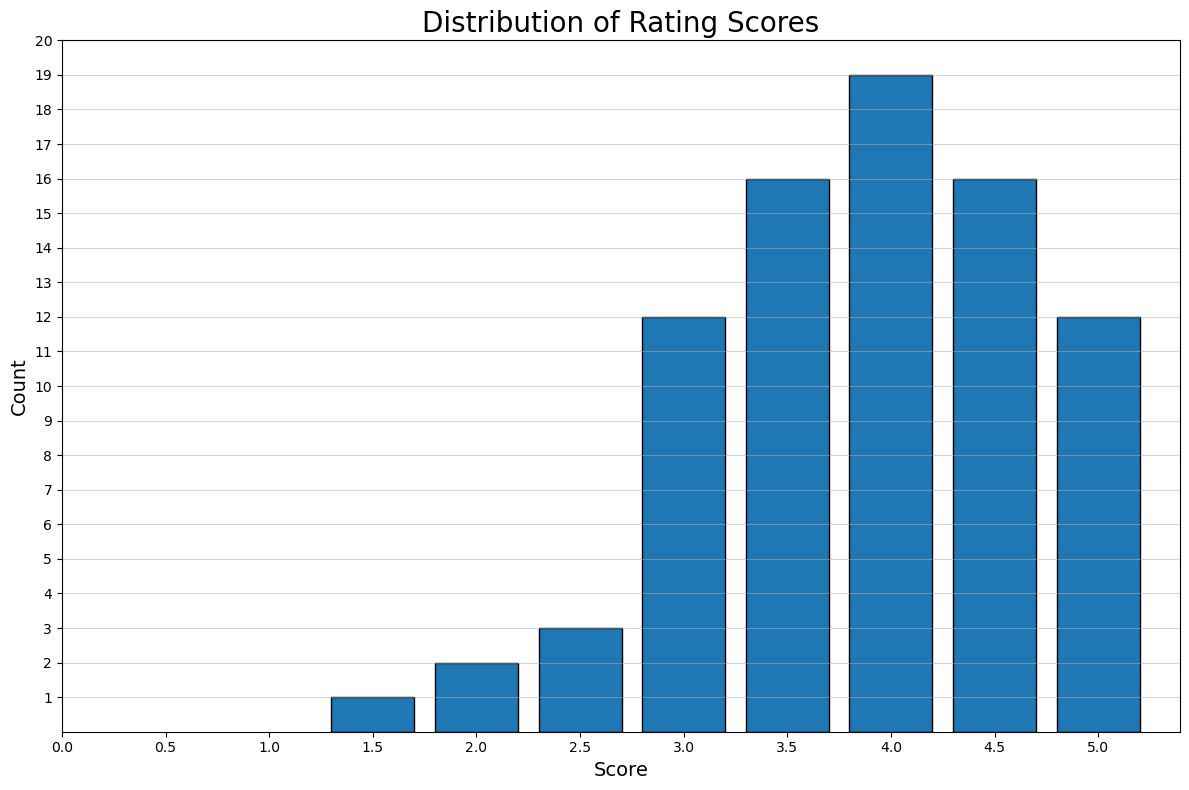

In [ ]:
# All possible ratings
pos_rate = [0, 0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0]

# Calculate frequencies of each rating
rating_counts = df_rate['Rating'].value_counts().sort_index()
print(rating_counts)
x = rating_counts.index
y = rating_counts.values

# Plot bar chart figure
plt.figure(figsize=(12, 8))
plt.bar(x, y, width=0.4, edgecolor='black')
plt.xticks(pos_rate)
plt.title('Distribution of Rating Scores', size=20)
plt.xlabel('Score', size=14)
plt.yticks([x + 1 for x in range(20)])
plt.ylabel('Count', size=14)
plt.grid(axis='y', alpha=0.5)
plt.tight_layout()
plt.show()


Inspect the relationship between ratings of the movie and the date I watched it (how my ratings change over time)

In [ ]:
# First reorder the dataset by date watched
df_rate = df_rate.sort_values('Date')
df_rate.head(20)

,Date,Name,Year,Letterboxd URI,Rating
0,2026-02-01,Fight Club,1999,https://boxd.it/2a9q,5.0
1,2026-02-01,Parasite,2019,https://boxd.it/hTha,5.0
2,2026-02-01,Pulp Fiction,1994,https://boxd.it/29Pq,4.5
3,2026-02-01,Good Will Hunting,1997,https://boxd.it/2ahY,5.0
5,2026-02-01,Weapons,2025,https://boxd.it/EMTM,3.0
6,2026-02-09,Casino Royale,2006,https://boxd.it/1alk,3.5
7,2026-02-14,Fargo,1996,https://boxd.it/2aHM,4.0
8,2026-02-15,Gonjiam: Haunted Asylum,2018,https://boxd.it/ioyw,2.5
14,2026-02-16,Dune,2021,https://boxd.it/fA7G,3.5
20,2026-02-16,Vanilla Sky,2001,https://boxd.it/27TK,3.0


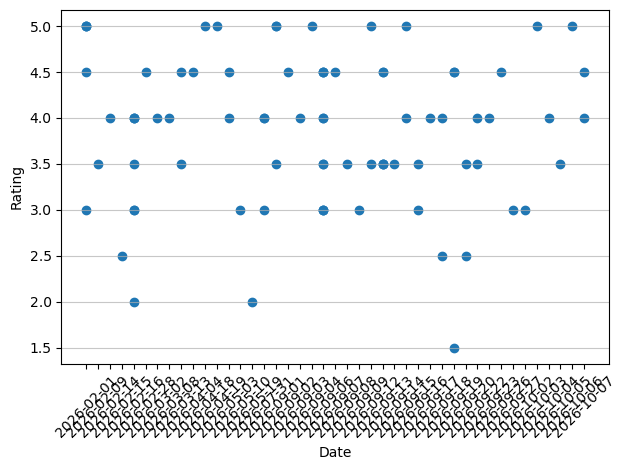

In [ ]:
# Scatter Plot of Movie ratings by date watched
plt.plot(figsize=(24, 24))
plt.scatter(df_rate['Date'], df_rate['Rating'])
plt.xlabel('Date')
plt.xticks(rotation=45)
plt.ylabel('Rating')
plt.grid(axis='y', alpha=0.7)
plt.tight_layout()
plt.show()
